# Ordinal Regression with LightGBMLSS

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/StatMixedML/LightGBMLSS/blob/master/docs/examples/OrderedLogistic_Regression.ipynb)

Ordinal data — discrete outcomes with a natural ordering such as Likert scales, severity grades, or star ratings — is ubiquitous in applied machine learning. Standard approaches either ignore the ordering (multinomial classification) or impose metric assumptions (treating labels as continuous integers). The **cumulative link model**, commonly called the *proportional odds* or *ordered logistic* model, is the principled middle ground.

It models the cumulative probabilities $P(y \leq k \mid x)$ as sigmoid functions of a latent score $\eta$ minus ordered cutpoints $c_1 < c_2 < \cdots < c_{K-1}$:

$$P(y \leq k \mid \eta) = \sigma(c_k - \eta), \quad k = 1, \ldots, K-1$$

so that the probability of each individual class is:

$$P(y = k \mid \eta) = \sigma(c_k - \eta) - \sigma(c_{k-1} - \eta)$$

with $\sigma(c_0 - \eta) = 0$ and $\sigma(c_K - \eta) = 1$ by convention.

LightGBMLSS estimates both the **latent predictor** $\eta(x)$ and the **cutpoints** $c_1, \ldots, c_{K-1}$ as functions of covariates. Monotonicity of cutpoints is enforced via a cumulative softplus reparameterisation:

$$c_1 = \text{raw}_1, \qquad c_k = c_1 + \sum_{j=2}^{k} \text{softplus}(\text{raw}_j), \quad k \geq 2$$

This gives $K$ unconstrained tree outputs (one per parameter), while guaranteeing strict ordering of the cutpoints at all times during training.

# Imports

In [1]:
from lightgbmlss.model import *
from lightgbmlss.distributions.OrderedLogistic import *

import numpy as np
import pandas as pd
from scipy.special import expit as sigmoid
from scipy.stats import kendalltau
from sklearn.metrics import confusion_matrix, cohen_kappa_score

import plotnine
from plotnine import *
plotnine.options.figure_size = (12, 8)

/Users/ekole/anaconda3/envs/ekole-ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

We simulate ordinal data from the cumulative logistic model with $K = 4$ classes (labels $\{0, 1, 2, 3\}$). The true data-generating process is:

- $\eta(x) = x_1 - 0.5 \, x_2 + 0.3 \, x_3 + 0.8 \, x_5$  (two noise features $x_4, x_5$ included)
- Cutpoints: $c_1 = -1.0,\; c_2 = 0.5,\; c_3 = 2.0$

Labels are drawn from $P(y = k \mid \eta)$ as defined above. We use 2 000 observations: 1 500 for training, 500 for testing.

In [2]:
np.random.seed(42)

n = 2000
K = 4
cutpoints_true = np.array([-1.0, 0.5, 2.0])

X = np.random.randn(n, 5)
eta_true = X @ np.array([1.0, -0.5, 0.3, 0.0, 0.8])

# Cumulative probabilities P(y <= k | eta)
cum_probs = sigmoid(cutpoints_true[np.newaxis, :] - eta_true[:, np.newaxis])  # (n, K-1)

# Class probabilities
p0 = cum_probs[:, 0]
p1 = cum_probs[:, 1] - cum_probs[:, 0]
p2 = cum_probs[:, 2] - cum_probs[:, 1]
p3 = 1.0 - cum_probs[:, 2]
probs = np.stack([p0, p1, p2, p3], axis=1)
probs = np.clip(probs, 1e-9, None)
probs /= probs.sum(axis=1, keepdims=True)

y = np.array([np.random.choice(K, p=probs[i]) for i in range(n)], dtype=float)

# Train / test split
X_train, X_test = X[:1500], X[1500:]
y_train, y_test = y[:1500], y[1500:]

X_train_df = pd.DataFrame(X_train, columns=[f"x{i+1}" for i in range(5)])
X_test_df  = pd.DataFrame(X_test,  columns=[f"x{i+1}" for i in range(5)])

dtrain = lgb.Dataset(X_train_df, label=y_train)

In [3]:
# Class distribution
pd.Series(y_train, name="class").value_counts().sort_index().rename("count")

class
0.0    515
1.0    384
2.0    330
3.0    271
Name: count, dtype: int64

# Distribution Specification

We specify the `OrderedLogistic` distribution with `K=4` ordinal classes. This adds one tree for the latent predictor $\eta$ and three trees for the raw cutpoint parameters — four trees per boosting round in total.

Arguments:
- `n_classes`: number of ordinal categories $K$.
- `stabilization`: gradient/Hessian stabilization. Options are `"None"`, `"MAD"`, `"L2"`.
- `loss_fn`: only `"nll"` is supported for ordinal regression.
- `initialize`: if `True`, start-value optimisation via L-BFGS is run before boosting.

In [4]:
lgblss = LightGBMLSS(
    OrderedLogistic(
        n_classes=4,
        stabilization="L2",
        loss_fn="nll",
        initialize=True,
    )
)

# Hyper-Parameter Optimisation

Any LightGBM hyperparameter can be tuned. The parameter dictionary structure is:

    - Float/Int sample_type
        - {"param_name": ["sample_type", {"low": low, "high": high, "log": log}]}

    - Categorical sample_type
        - {"param_name": ["categorical", ["choice1", "choice2", ...]]}

In [5]:
param_dict = {
    "eta":                     ["float", {"low": 1e-5,  "high": 1,    "log": True}],
    "max_depth":               ["int",   {"low": 1,     "high": 6,    "log": False}],
    "num_leaves":              ["int",   {"low": 255,   "high": 255,  "log": False}],  # fixed for this example
    "min_data_in_leaf":        ["int",   {"low": 20,    "high": 20,   "log": False}],  # fixed for this example
    "min_gain_to_split":       ["float", {"low": 1e-8,  "high": 40,   "log": False}],
    "min_sum_hessian_in_leaf": ["float", {"low": 1e-8,  "high": 500,  "log": True}],
    "subsample":               ["float", {"low": 0.2,   "high": 1.0,  "log": False}],
    "feature_fraction":        ["float", {"low": 0.2,   "high": 1.0,  "log": False}],
    "boosting":                ["categorical", ["gbdt"]],
}

np.random.seed(123)
opt_param = lgblss.hyper_opt(
    param_dict,
    dtrain,
    num_boost_round=200,
    nfold=5,
    early_stopping_rounds=20,
    max_minutes=10,
    n_trials=30,
    silence=True,
    seed=123,
    hp_seed=123,
)

Best trial: 11. Best value: 1.17732: 100%|██████████| 30/30 [00:27<00:00,  1.08it/s, 27.89/600 seconds]


Hyper-Parameter Optimization successfully finished.
  Number of finished trials:  30
  Best trial:
    Value: 1.1773182786700325
    Params: 
    eta: 0.17844445339780893
    max_depth: 1
    num_leaves: 255
    min_data_in_leaf: 20
    min_gain_to_split: 0.6172009257451649
    min_sum_hessian_in_leaf: 1.7679789696512058e-08
    subsample: 0.9979013632487388
    feature_fraction: 0.4678590887770889
    boosting: gbdt
    opt_rounds: 80


# Model Training

In [6]:
np.random.seed(123)

opt_params = opt_param.copy()
n_rounds = opt_params["opt_rounds"]
del opt_params["opt_rounds"]

lgblss.train(
    opt_params,
    dtrain,
    num_boost_round=n_rounds,
)

# Prediction

`OrderedLogistic` supports four prediction types:

- `"parameters"` — latent predictor $\hat{\eta}$ and ordered cutpoints $\hat{c}_1 \ldots \hat{c}_{K-1}$.
- `"class_probs"` — $\hat{P}(y = k)$ for each class $k \in \{0, 1, 2, 3\}$.
- `"samples"` — ordinal class samples drawn from the predicted distribution.
- `"quantiles"` — quantiles derived from the sample-based distribution.

In [7]:
torch.manual_seed(123)

# Predicted distributional parameters (predictor + ordered cutpoints)
pred_params = lgblss.predict(X_test_df, pred_type="parameters")

# Predicted class probabilities P(y=k) for k in {0,1,2,3}
pred_probs = lgblss.predict(X_test_df, pred_type="class_probs")

# Samples from predicted distribution
pred_samples = lgblss.predict(X_test_df, pred_type="samples", n_samples=1000, seed=123)

# Quantiles from predicted distribution
pred_quantiles = lgblss.predict(X_test_df, pred_type="quantiles",
                                 n_samples=1000, quantiles=[0.1, 0.5, 0.9])

In [8]:
pred_params.head()

,predictor,cutpoint_1,cutpoint_2,cutpoint_3
0,1.369483,-0.152057,0.891562,2.106802
1,-0.586508,0.941386,2.862761,3.739857
2,0.979903,0.489640,1.712716,3.624045
3,0.756909,0.166980,1.493032,3.455083
4,1.401499,-0.757049,0.583434,1.961357


In [9]:
pred_probs.head()

,P(y=0),P(y=1),P(y=2),P(y=3)
0,0.179235,0.203508,0.293666,0.323591
1,0.821698,0.147511,0.017748,0.013043
2,0.379832,0.295591,0.258227,0.066351
3,0.356651,0.319497,0.260771,0.063081
4,0.103535,0.202639,0.330245,0.363580


In [10]:
pred_quantiles.head()

,quant_0.1,quant_0.5,quant_0.9
0,0,2,3
1,0,0,1
2,0,1,2
3,0,1,2
4,0,2,3


# Evaluation

We evaluate the model using metrics appropriate for ordinal regression:

- **Accuracy** — exact class match.
- **MAE** — mean absolute error on class labels (penalises larger ordinal misses more).
- **Kendall's $\tau$** — rank correlation between predicted and actual classes.
- **Quadratic Weighted Kappa (QWK)** — Cohen's $\kappa$ with quadratic weights; standard for ordinal agreement.

In [11]:
# Most probable class = argmax of P(y=k)
y_pred_class = pred_probs.values.argmax(axis=1)
y_true = y_test.astype(int)

accuracy = (y_pred_class == y_true).mean()
mae = np.abs(y_pred_class - y_true).mean()
tau, _ = kendalltau(y_pred_class, y_true)
qwk = cohen_kappa_score(y_true, y_pred_class, weights="quadratic")

print(f"Accuracy : {accuracy:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"Kendall τ: {tau:.4f}")
print(f"QWK      : {qwk:.4f}")

Accuracy : 0.4560
MAE      : 0.7460
Kendall τ: 0.4665
QWK      : 0.5257


### Confusion Matrix

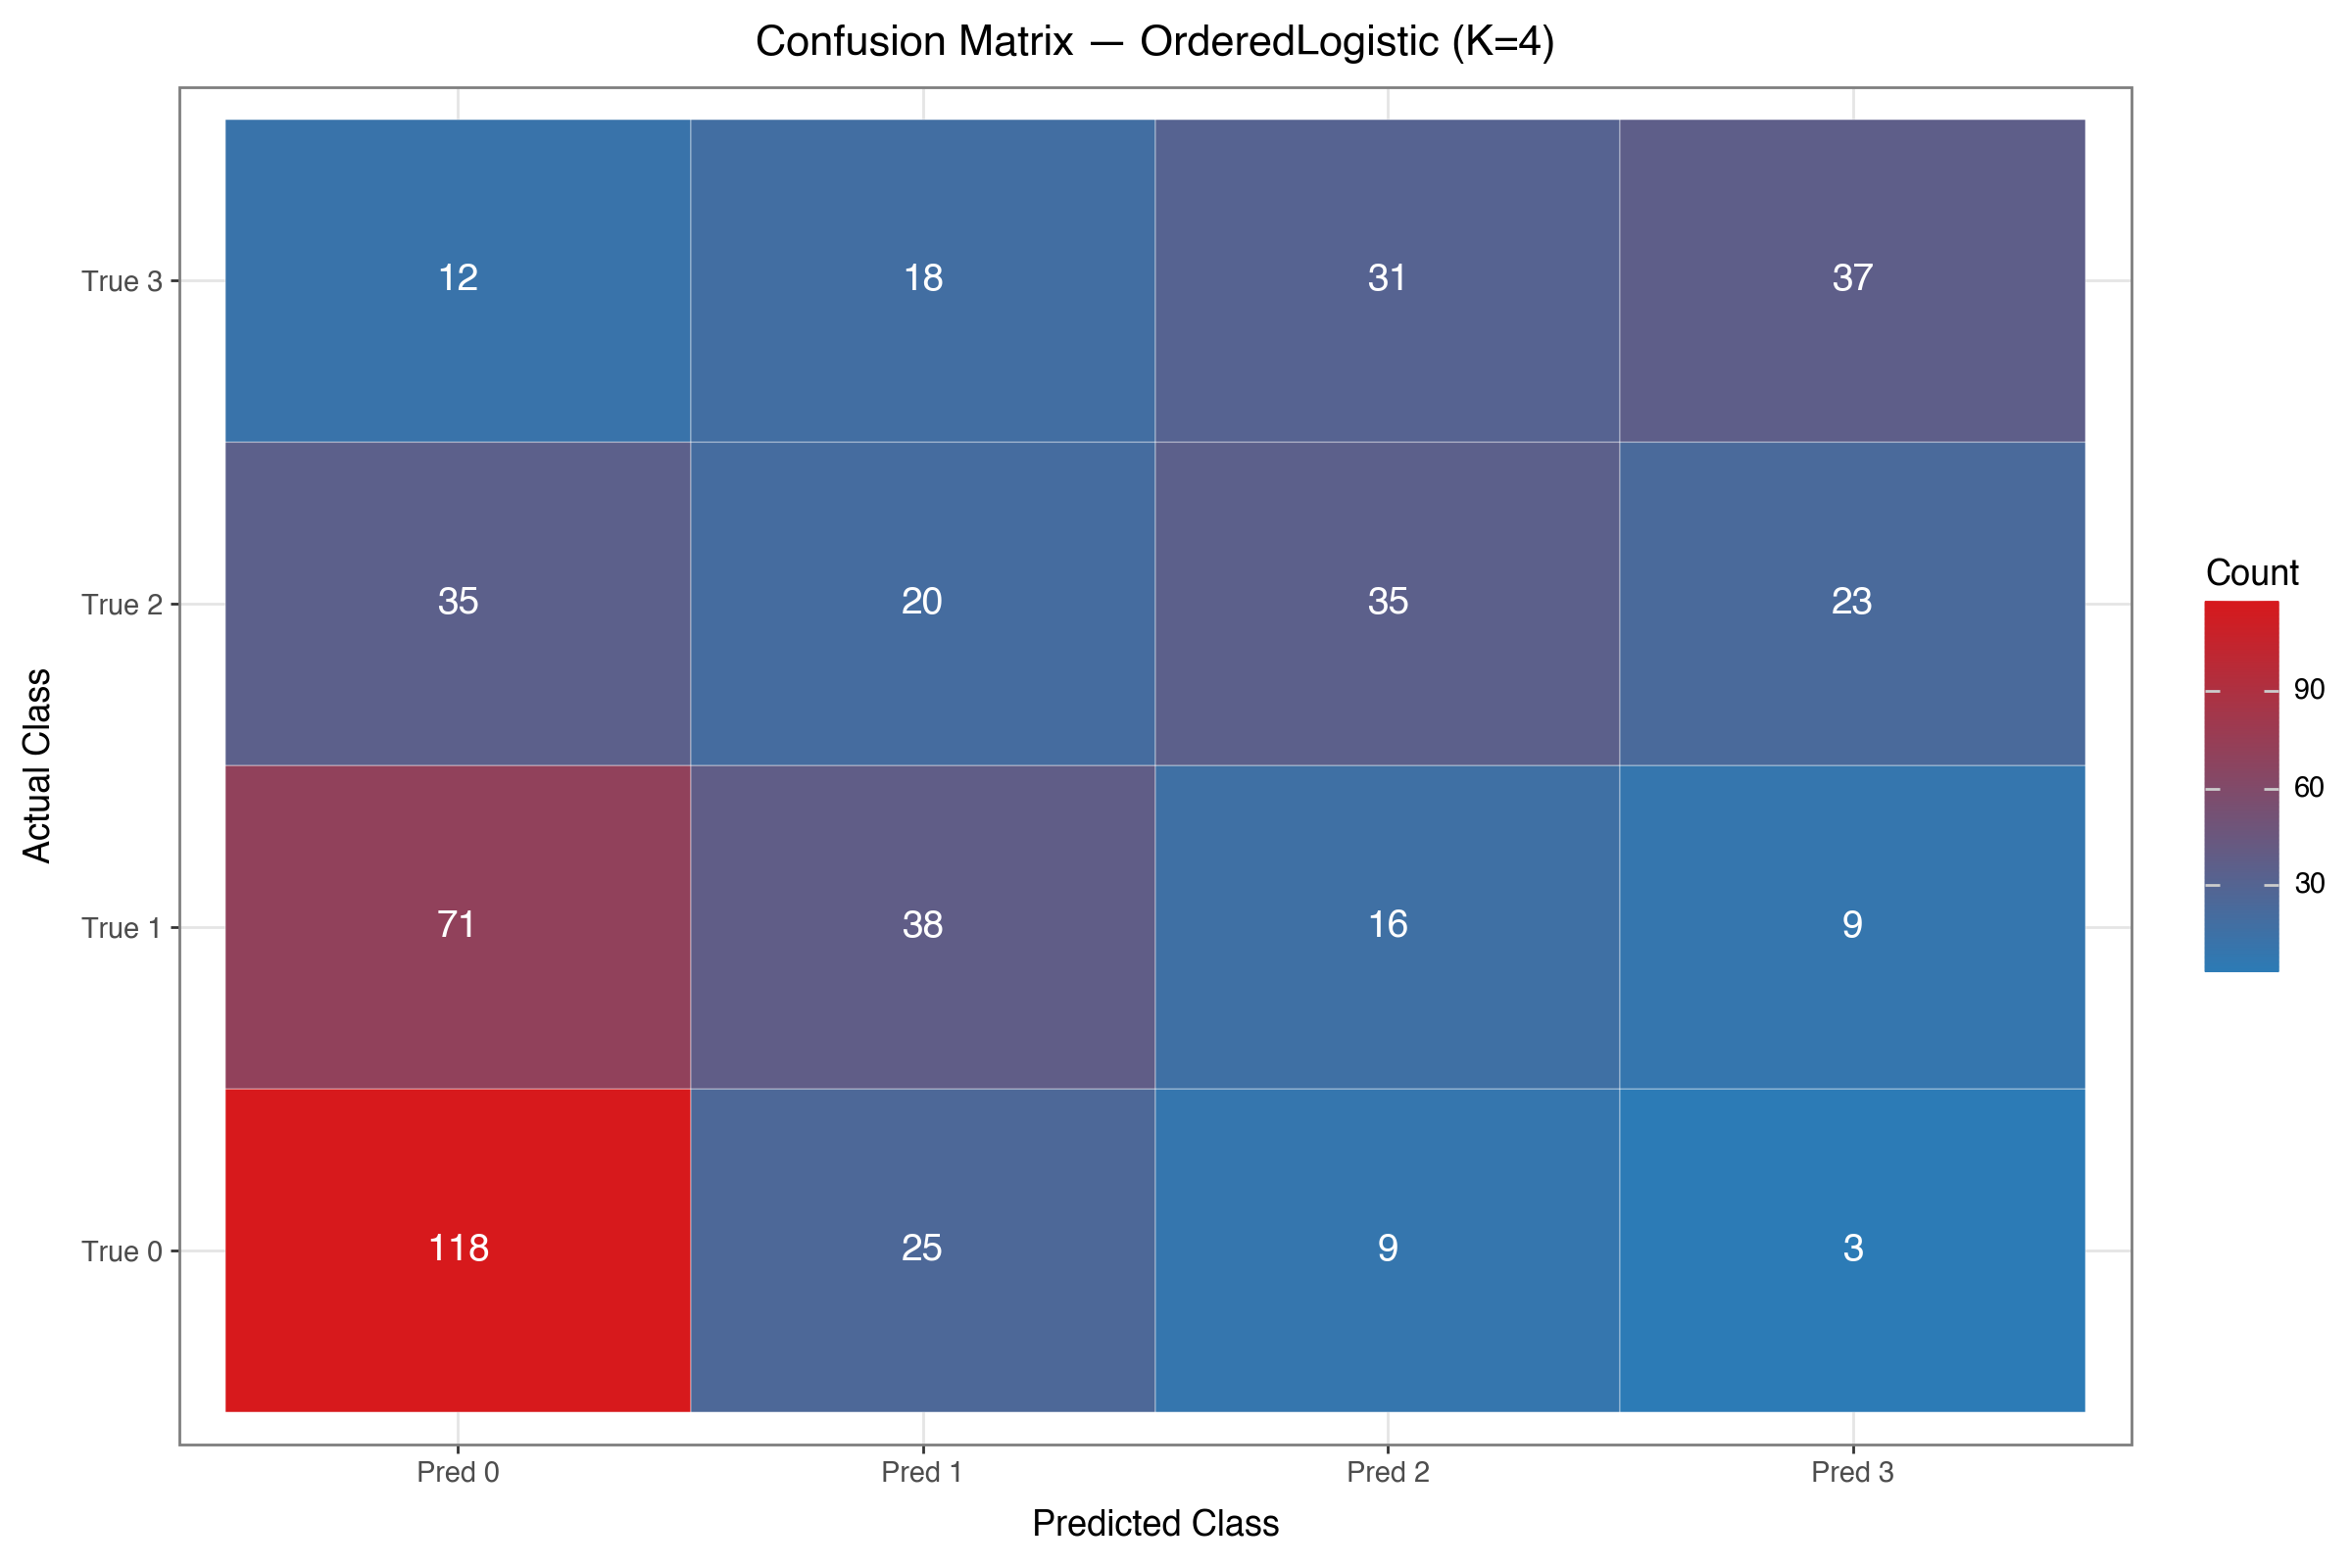

In [12]:
cm = confusion_matrix(y_true, y_pred_class)
cm_df = (
    pd.DataFrame(cm,
                 index=[f"True {k}"  for k in range(K)],
                 columns=[f"Pred {k}" for k in range(K)])
    .reset_index()
    .melt(id_vars="index", var_name="Predicted", value_name="Count")
    .rename(columns={"index": "Actual"})
)

(
    ggplot(cm_df, aes(x="Predicted", y="Actual", fill="Count")) +
    geom_tile(color="white") +
    geom_text(aes(label="Count"), size=14, color="white") +
    scale_fill_gradient(low="#2c7bb6", high="#d7191c") +
    labs(
        title="Confusion Matrix — OrderedLogistic (K=4)",
        x="Predicted Class",
        y="Actual Class",
    ) +
    theme_bw(base_size=13) +
    theme(
        plot_title=element_text(hjust=0.5),
        legend_position="right",
    )
)

### Predicted Class Probability Distributions

For each test observation we obtain a full probability vector $\hat{P}(y = k)$ over all four classes. Below we plot these distributions, grouped by the true class label, to inspect calibration and sharpness.

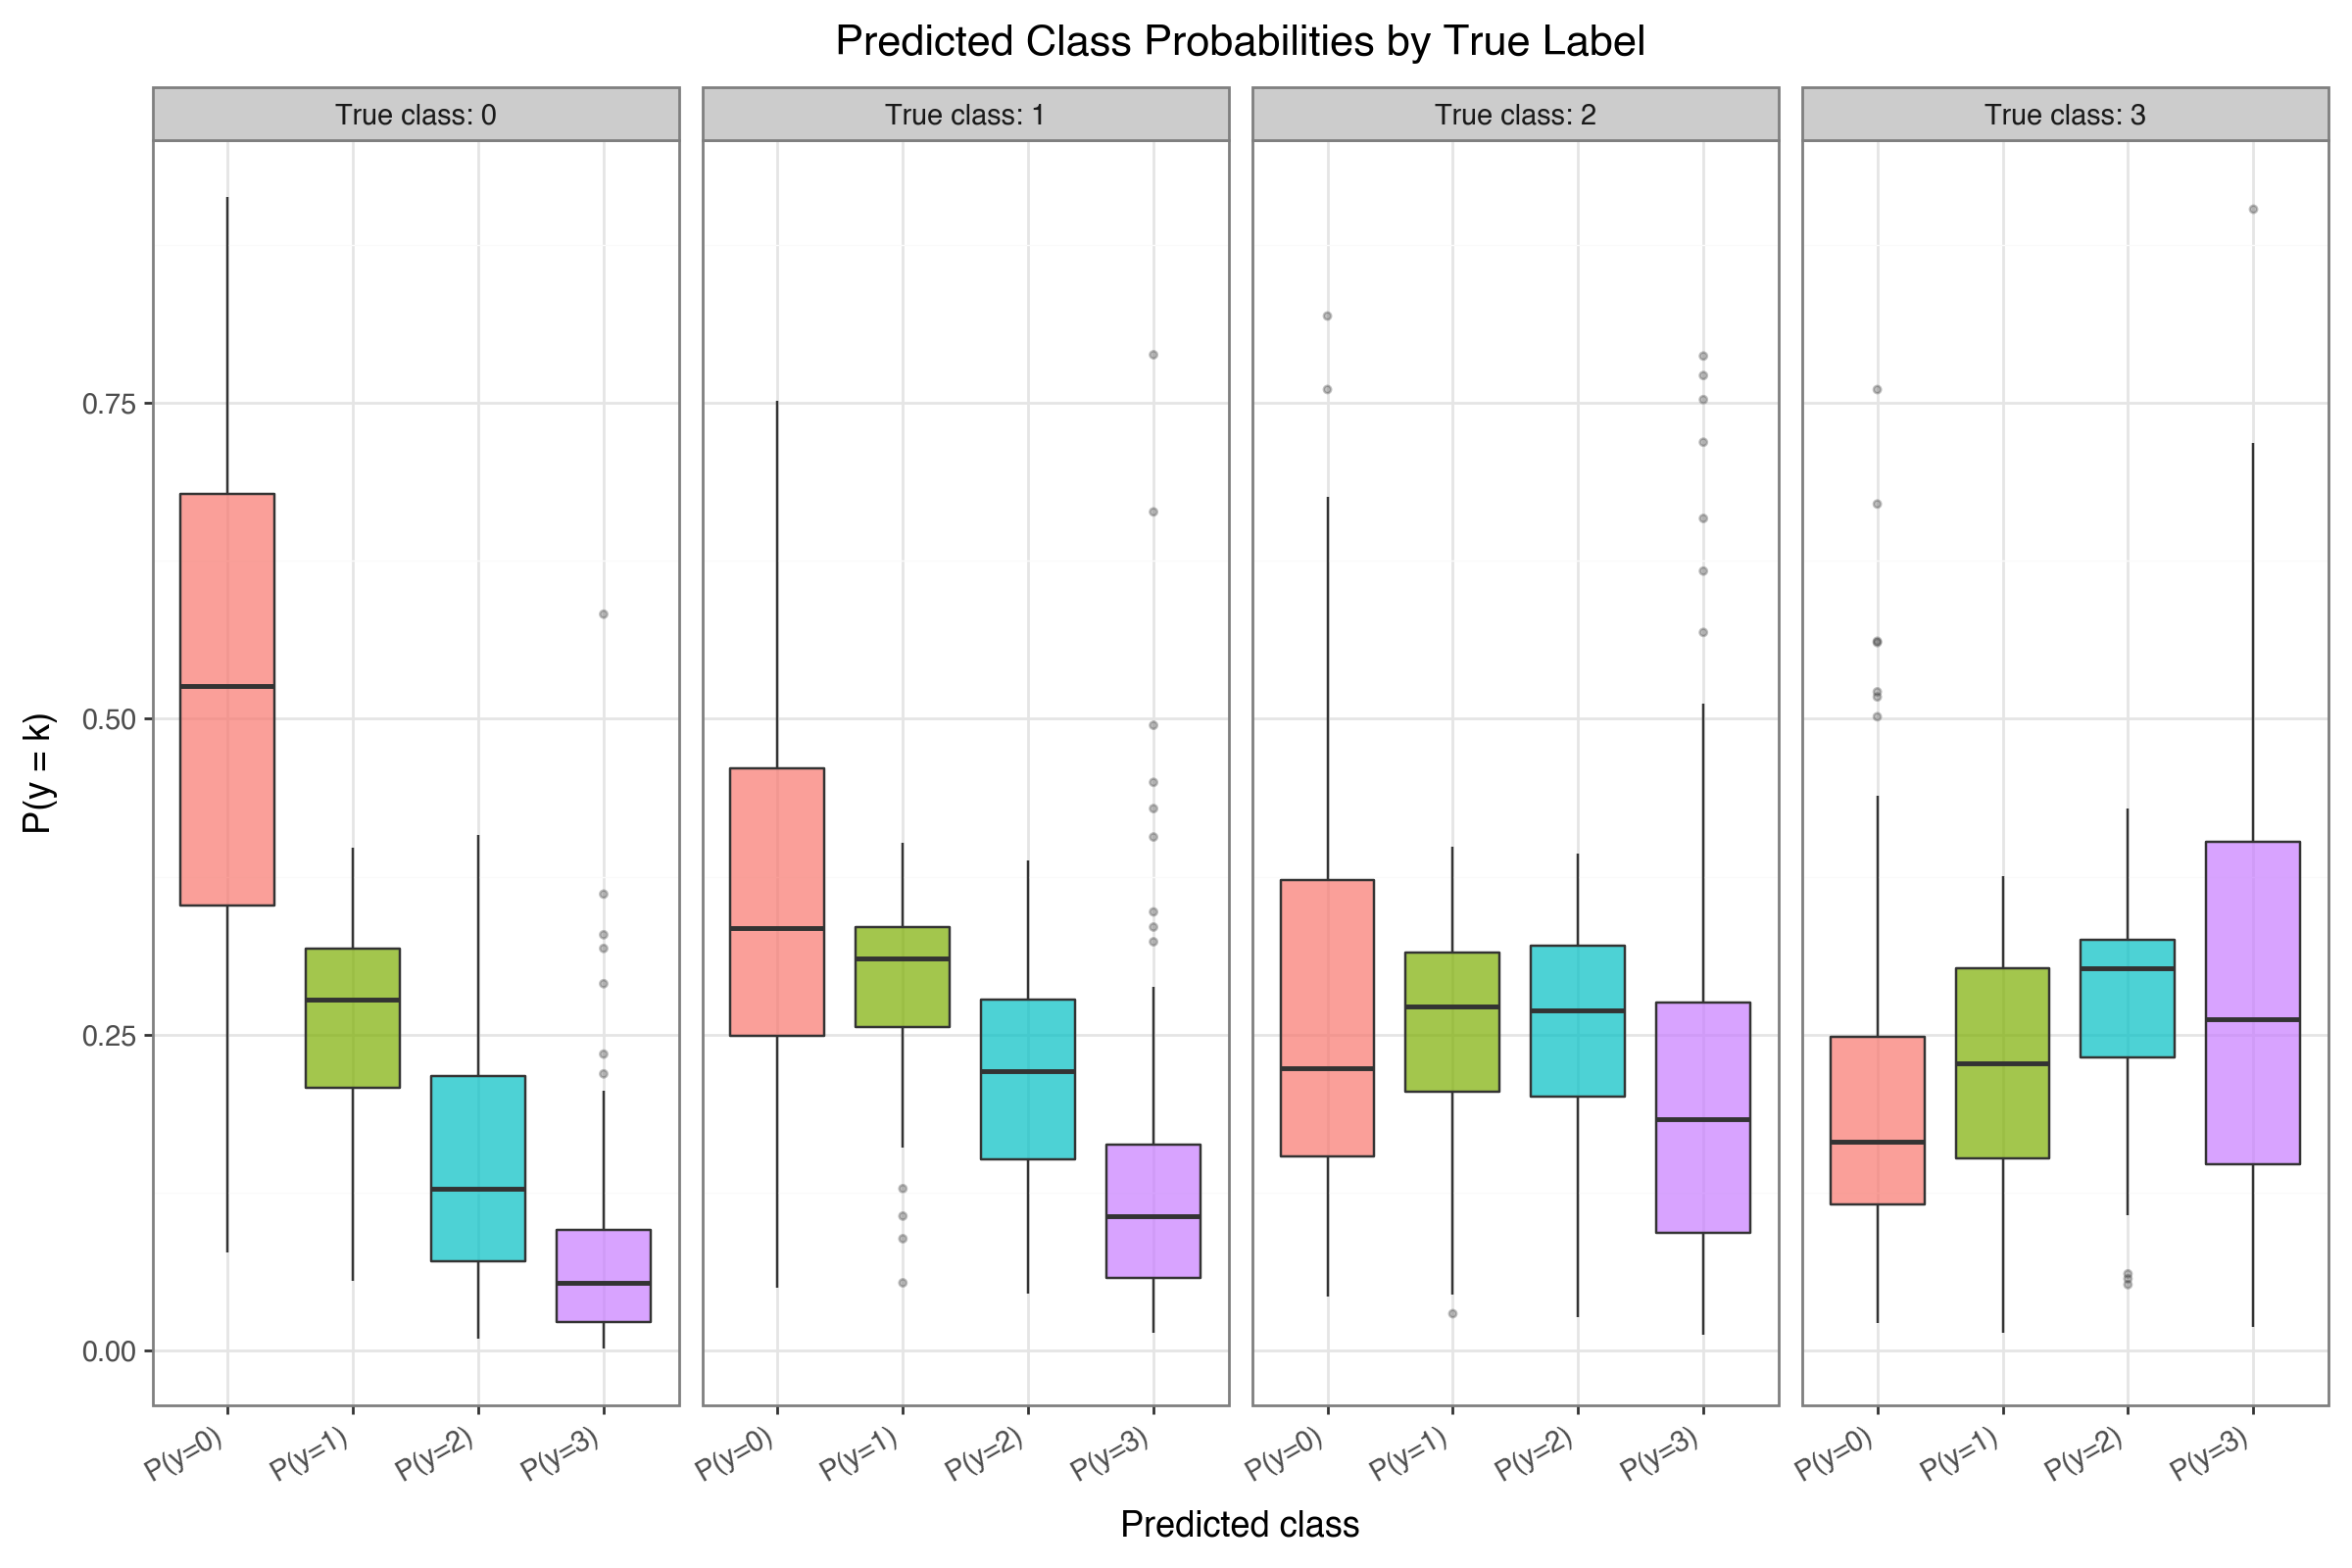

In [13]:
prob_df = pred_probs.copy()
prob_df["true_class"] = y_true
prob_long = prob_df.melt(
    id_vars="true_class",
    value_vars=[f"P(y={k})" for k in range(K)],
    var_name="class",
    value_name="probability",
)
prob_long["true_class"] = "True class: " + prob_long["true_class"].astype(str)

(
    ggplot(prob_long, aes(x="class", y="probability", fill="class")) +
    geom_boxplot(alpha=0.7, outlier_alpha=0.3, outlier_size=1) +
    facet_wrap("true_class", nrow=1) +
    labs(
        title="Predicted Class Probabilities by True Label",
        x="Predicted class",
        y="P(y = k)",
    ) +
    theme_bw(base_size=13) +
    theme(
        plot_title=element_text(hjust=0.5),
        legend_position="none",
        axis_text_x=element_text(rotation=30, hjust=1),
    )
)

### True vs. Predicted Cutpoints

The true cutpoints are $c_1 = -1.0$, $c_2 = 0.5$, $c_3 = 2.0$. The model learns one cutpoint set per observation (the cumulative logistic allows covariate-dependent cutpoints). We compare the median predicted cutpoints against the true values.

In [14]:
cutpoint_cols = [c for c in pred_params.columns if c.startswith("cutpoint")]
median_cutpoints = pred_params[cutpoint_cols].median()

print("Median predicted cutpoints:")
for name, val, true in zip(cutpoint_cols, median_cutpoints, cutpoints_true):
    print(f"  {name}: predicted = {val:.3f}  |  true = {true:.3f}")

Median predicted cutpoints:
  cutpoint_1: predicted = -0.002  |  true = -1.000
  cutpoint_2: predicted = 1.364  |  true = 0.500
  cutpoint_3: predicted = 2.766  |  true = 2.000


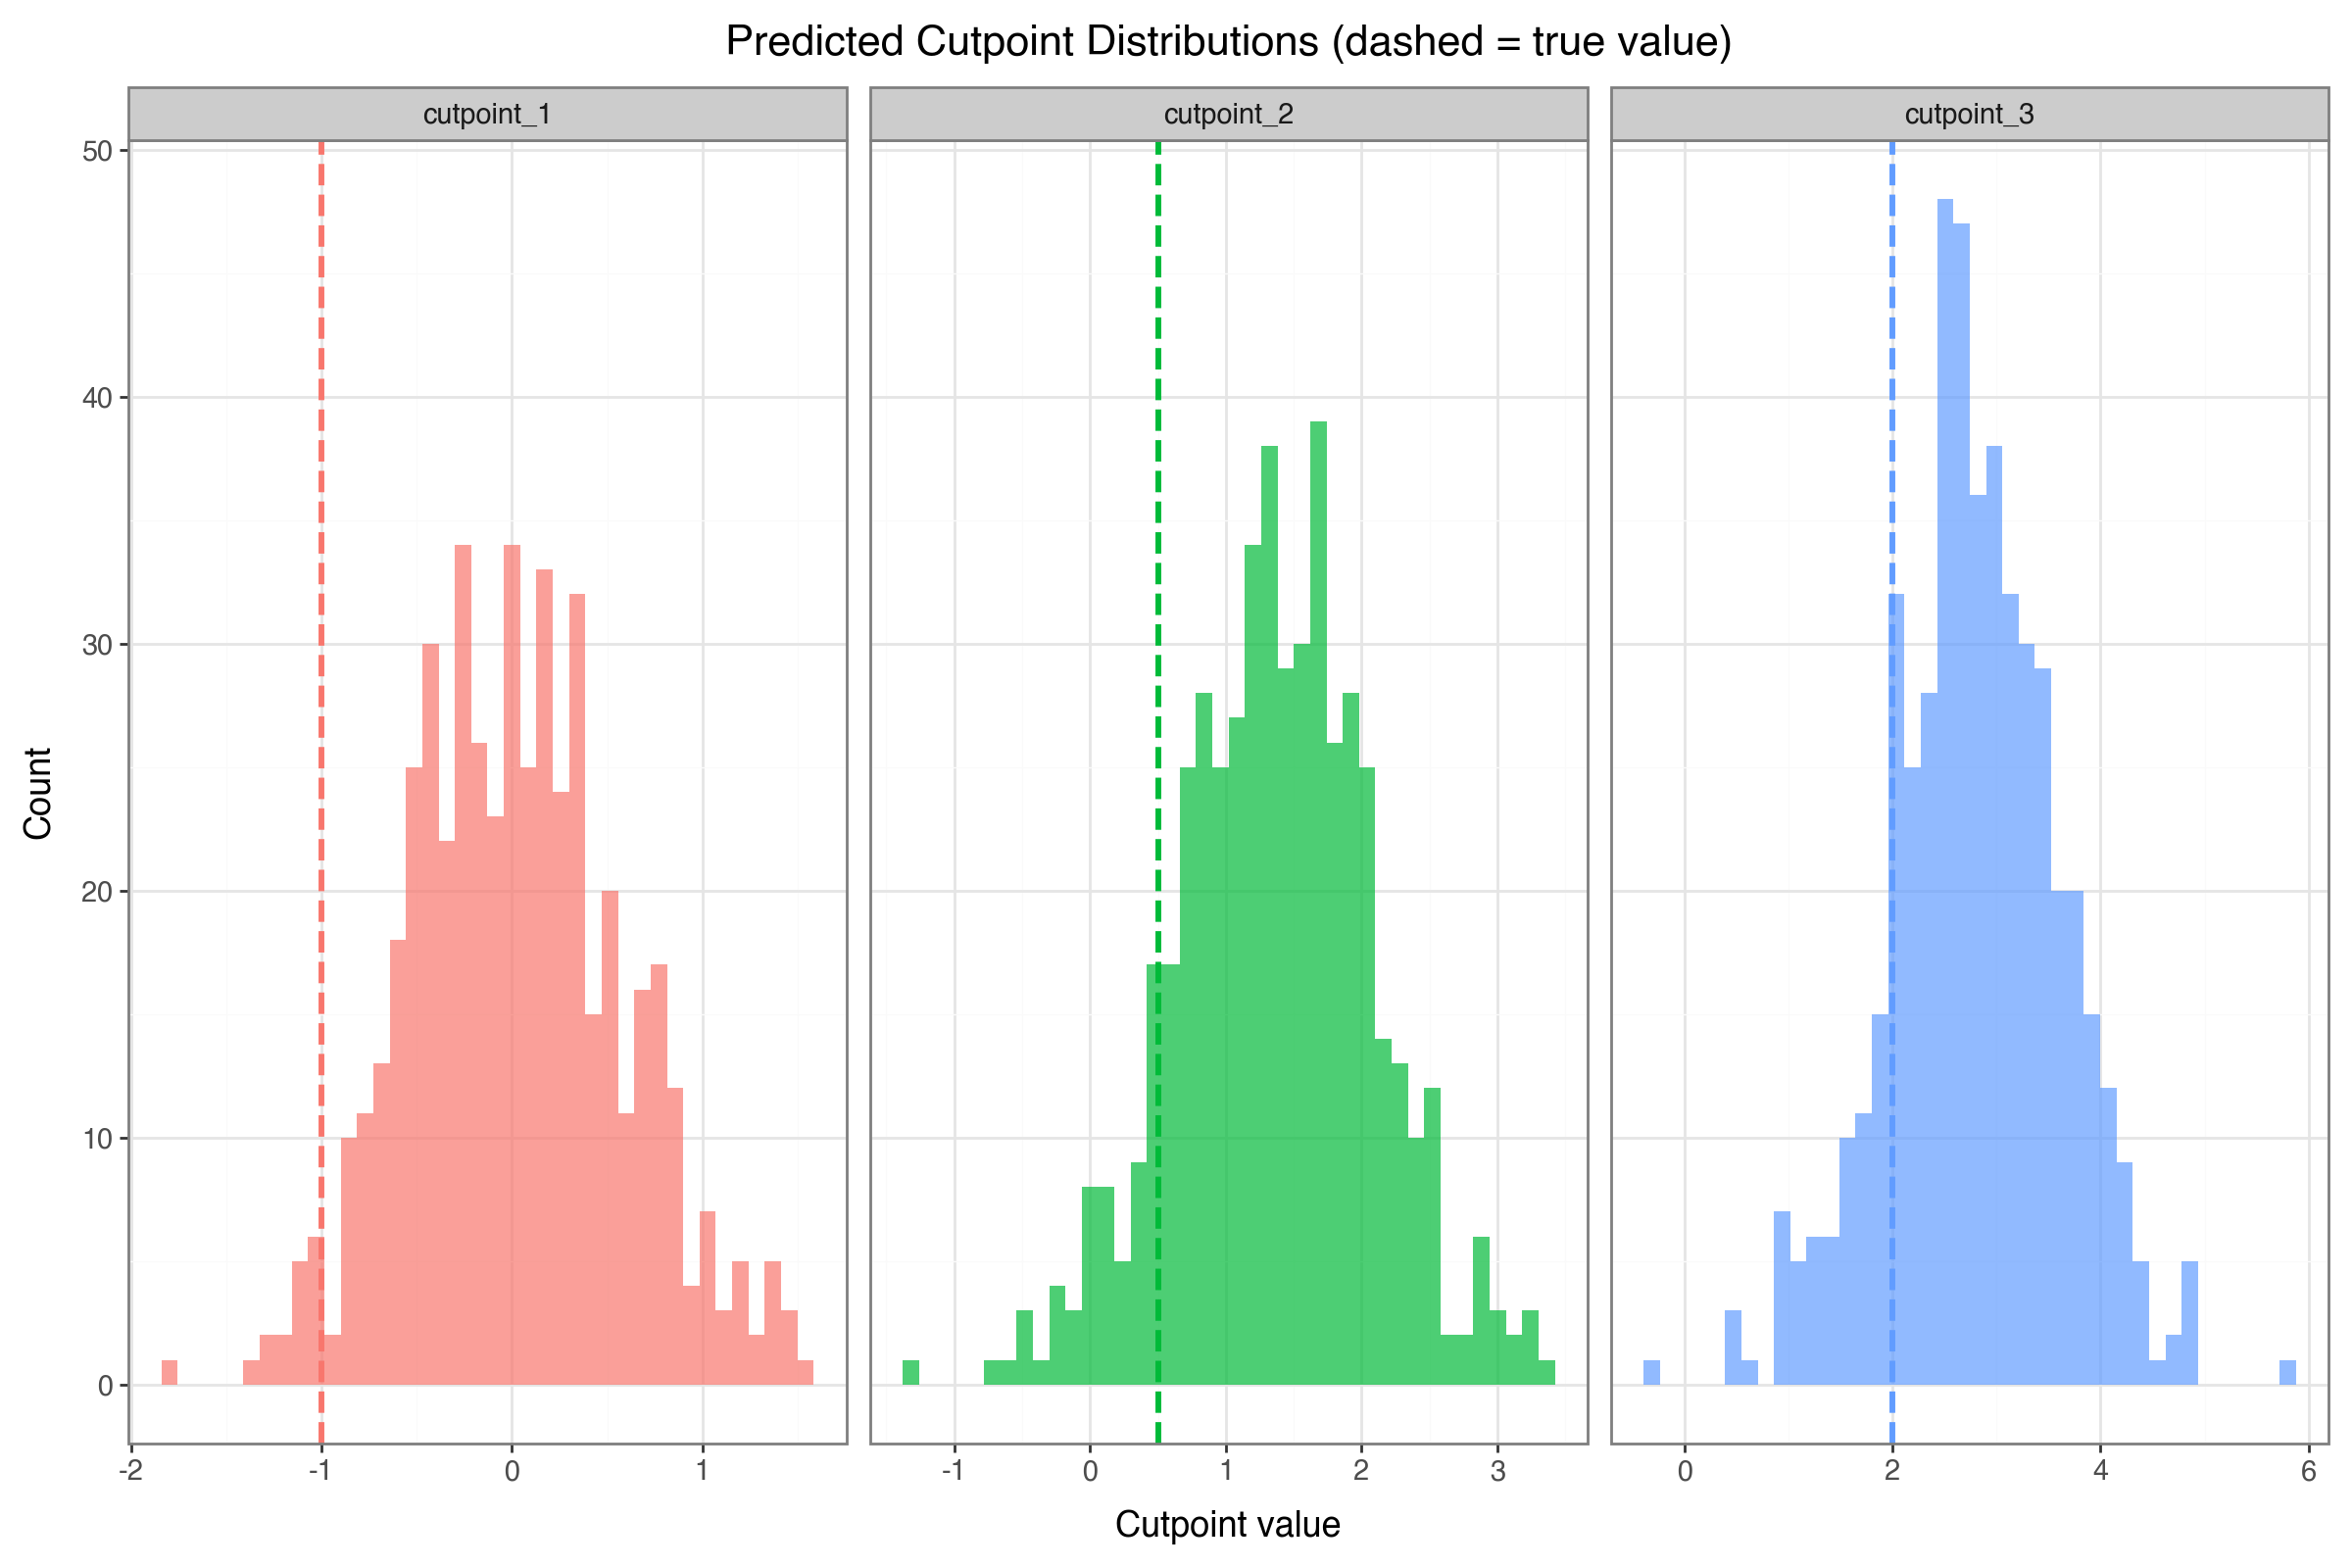

In [15]:
cp_long = pred_params[cutpoint_cols].melt(var_name="cutpoint", value_name="value")

true_cp_df = pd.DataFrame({
    "cutpoint": cutpoint_cols,
    "true_value": cutpoints_true,
})

(
    ggplot(cp_long, aes(x="value", fill="cutpoint")) +
    geom_histogram(bins=40, alpha=0.7, position="identity") +
    geom_vline(
        true_cp_df,
        aes(xintercept="true_value", color="cutpoint"),
        size=1.2,
        linetype="dashed",
    ) +
    facet_wrap("cutpoint", scales="free_x") +
    labs(
        title="Predicted Cutpoint Distributions (dashed = true value)",
        x="Cutpoint value",
        y="Count",
    ) +
    theme_bw(base_size=13) +
    theme(
        plot_title=element_text(hjust=0.5),
        legend_position="none",
    )
)

# SHAP Interpretability

LightGBMLSS provides attribute importance and partial dependence plots via SHAP. For the ordered logistic model the key parameter is the **predictor** $\eta$, which drives the latent score and thereby the class probabilities.

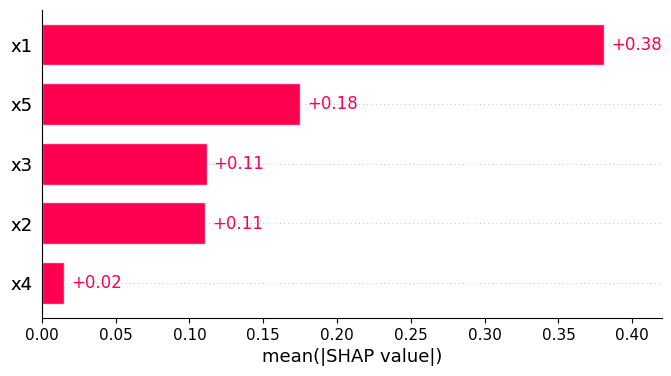

In [16]:
# Feature importance for the latent predictor
lgblss.plot(
    X_test_df,
    parameter="predictor",
    plot_type="Feature_Importance",
)

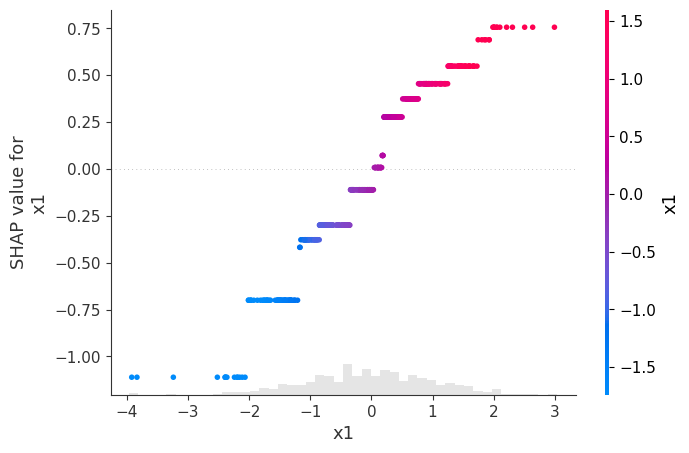

In [17]:
# Partial dependence: how x1 influences the latent predictor
lgblss.plot(
    X_test_df,
    parameter="predictor",
    feature="x1",
    plot_type="Partial_Dependence",
)

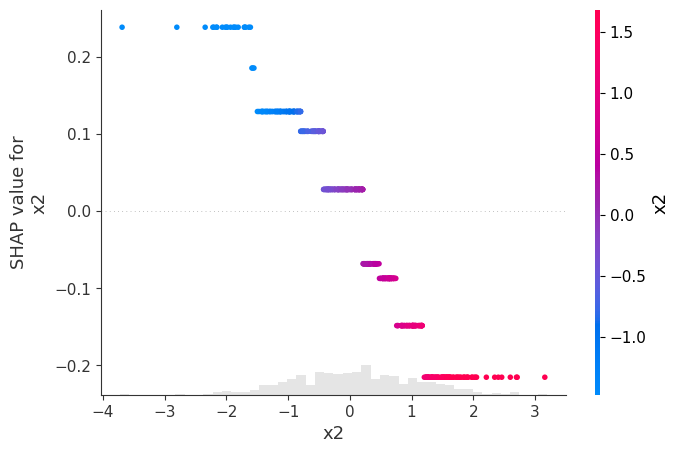

In [18]:
# Partial dependence for x2 (negative true coefficient)
lgblss.plot(
    X_test_df,
    parameter="predictor",
    feature="x2",
    plot_type="Partial_Dependence",
)

# Predicted Class Probabilities vs. Latent Predictor

A clean diagnostic is to plot $\hat{P}(y = k)$ as a function of the predicted latent score $\hat{\eta}$. Under the proportional odds model, class 0 should dominate at low $\hat{\eta}$ and class 3 at high $\hat{\eta}$, with the middle classes peaking in between.

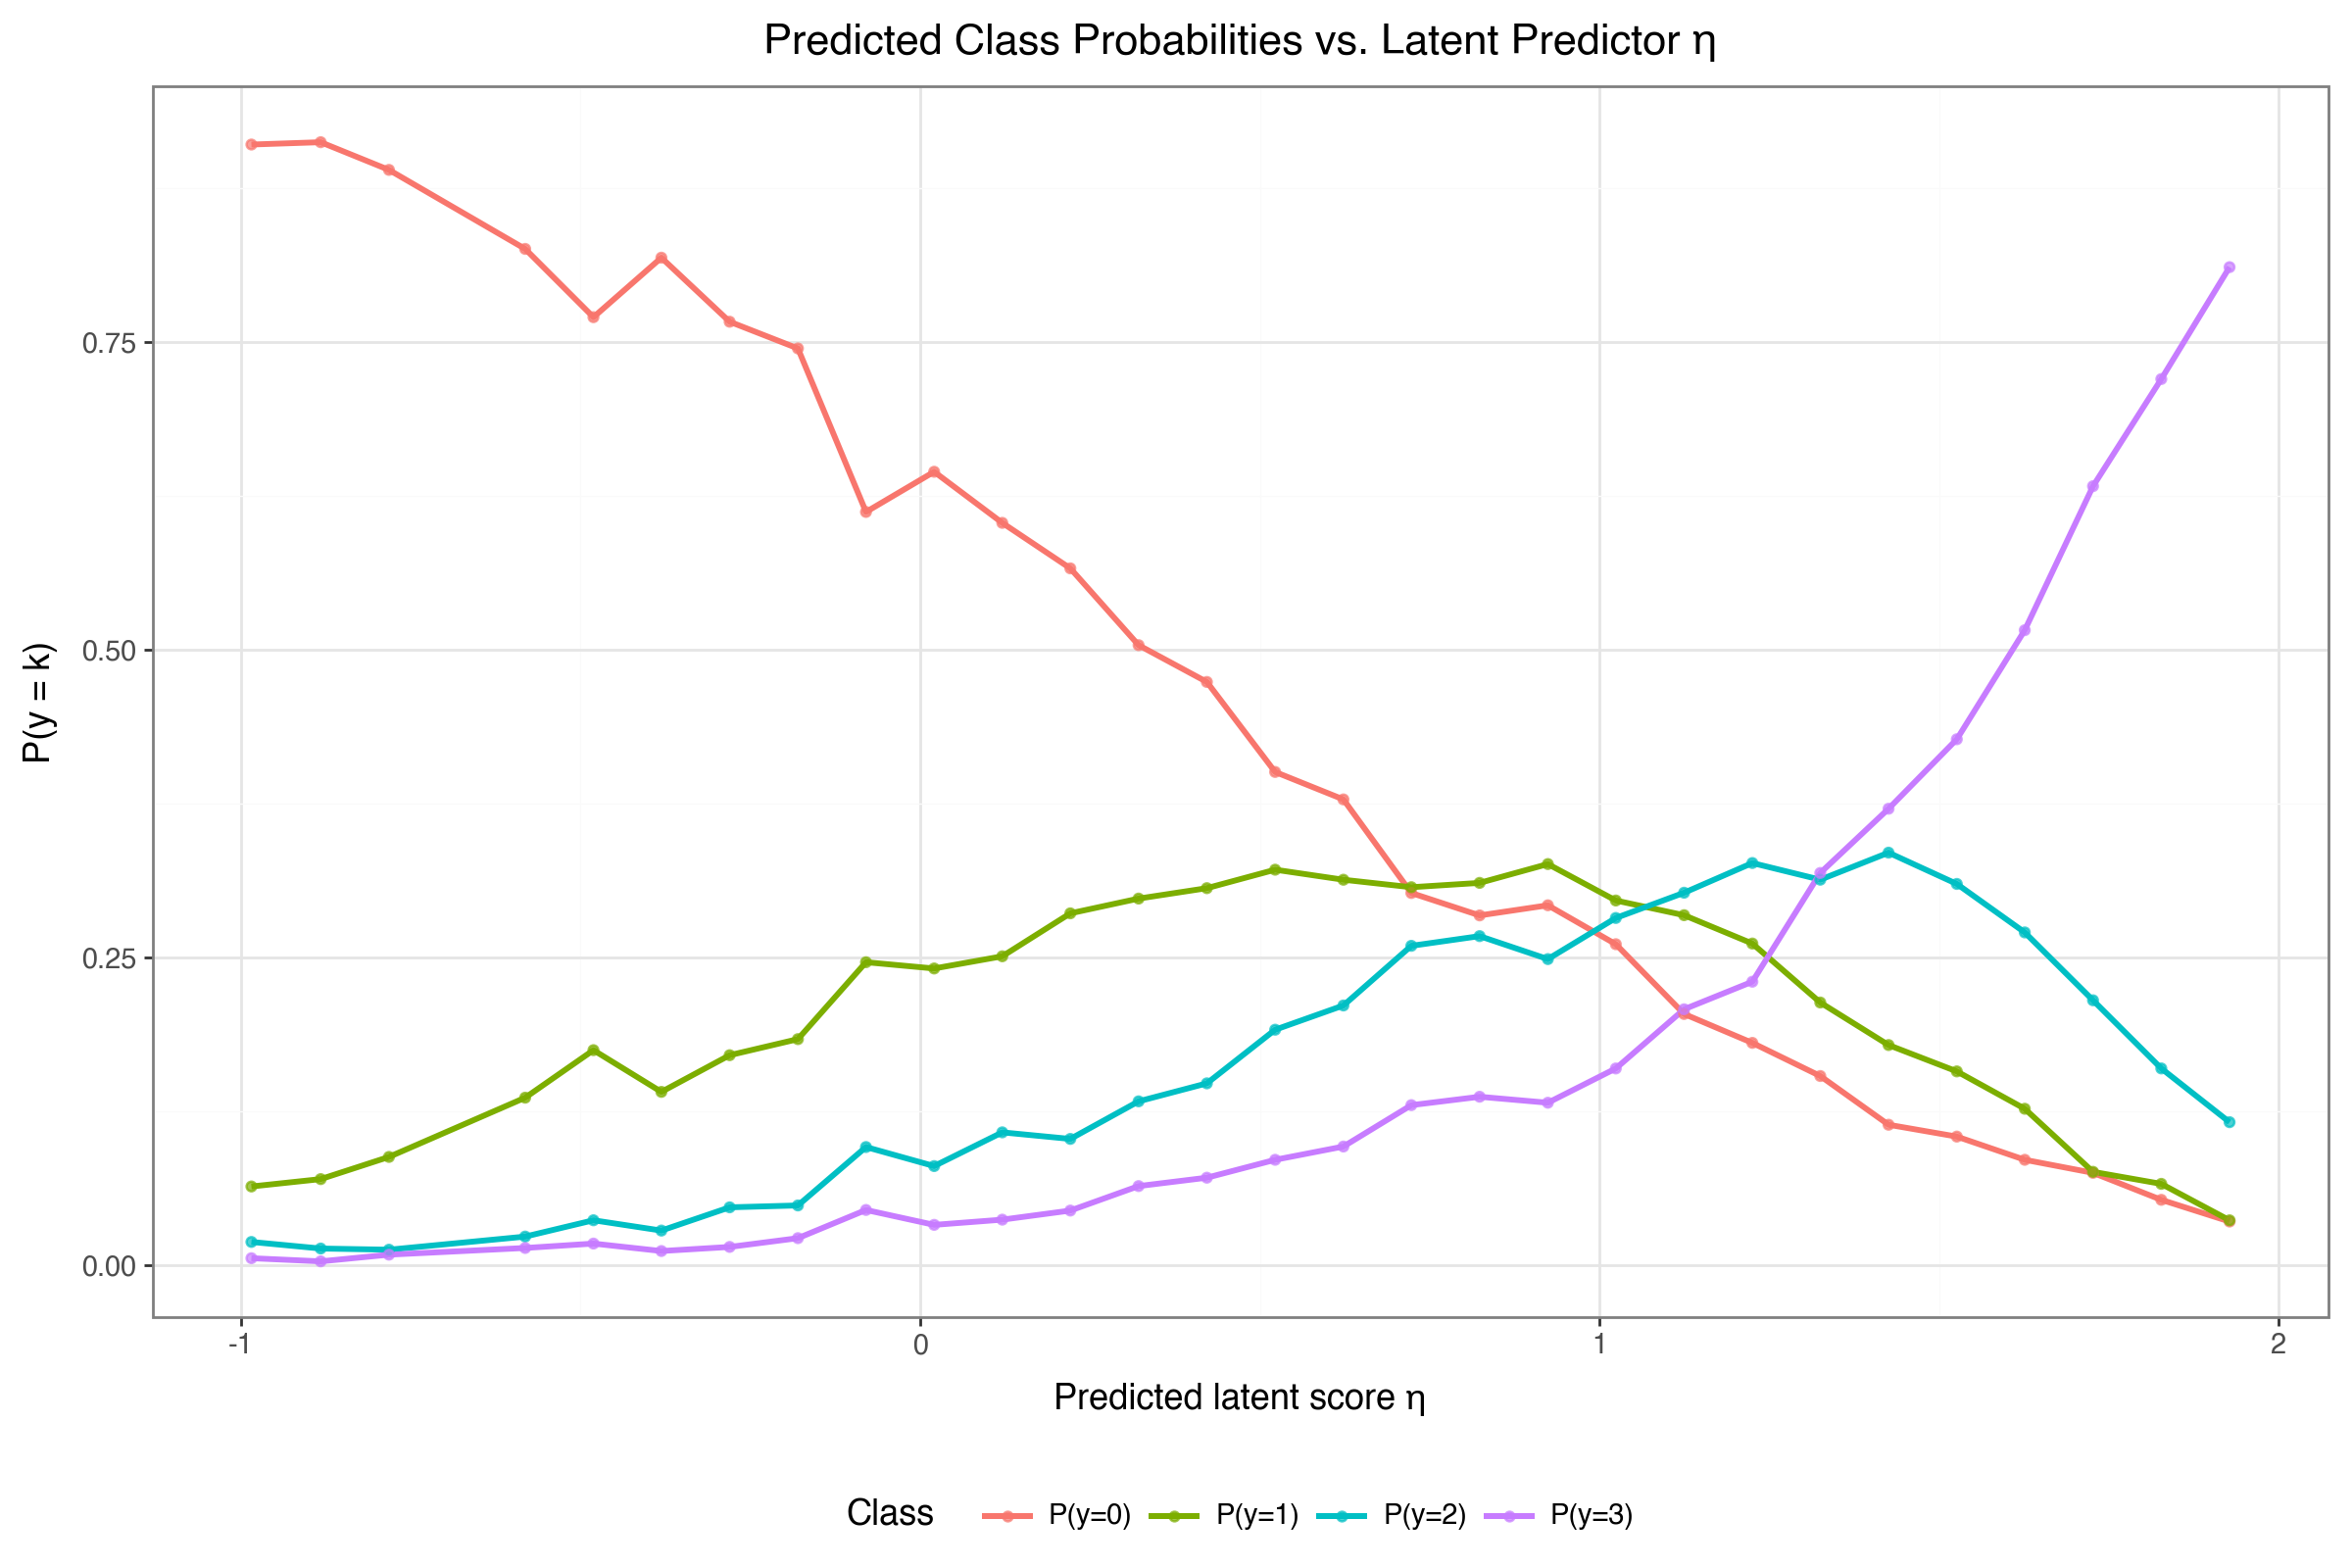

In [20]:
plot_df = pred_probs.copy()
plot_df["eta"] = pred_params["predictor"].values

plot_long = plot_df.melt(
    id_vars="eta",
    value_vars=[f"P(y={k})" for k in range(K)],
    var_name="class",
    value_name="probability",
)

# Bin eta into 30 equal-width intervals and compute mean P(y=k) per bin
plot_long["eta_bin"] = pd.cut(plot_long["eta"], bins=30)
binned = (
    plot_long
    .groupby(["eta_bin", "class"], observed=True)["probability"]
    .mean()
    .reset_index()
)
binned["eta_mid"] = binned["eta_bin"].apply(lambda x: x.mid).astype(float)

(
    ggplot(binned, aes(x="eta_mid", y="probability", color="class")) +
    geom_line(size=1.2) +
    geom_point(size=1.5, alpha=0.7) +
    labs(
        title="Predicted Class Probabilities vs. Latent Predictor \u03b7",
        x="Predicted latent score \u03b7",
        y="P(y = k)",
        color="Class",
    ) +
    theme_bw(base_size=13) +
    theme(
        plot_title=element_text(hjust=0.5),
        legend_position="bottom",
    )
)